# HPO Baseline (XLM-R Large) (v2) - head search

The single-view baseline searches its **own** head configuration, over the same
space and with the same budget as every other architecture that has a head of
its own (`config.HPO_SEARCHES`).

This matters. `AutoModelForSequenceClassification` puts a randomly initialised
classification head on top of the pretrained encoder. Training that head at the
encoder learning rate leaves it under-trained and would make the baseline an
unfairly weak point of comparison: a newly initialised head needs a considerably
higher rate than the pretrained body (Howard and Ruder, 2018). The head therefore
gets its own parameter group and its own searched `head_lr`, exactly like the
dual-view head, and `classifier_dropout` is the baseline's counterpart to the
dual-view head dropout.

Fixed and identical for every architecture (`config.FIXED_ENCODER`): batch 32,
encoder_lr 1e-5, weight_decay 0.01, warmup 0.1. Searched: `head_lr`, `dropout`,
`epochs`.

The validation slice uses `HPO_SLICE_SEED` (not the fold-assignment seed) and is
built from exactly the same rows as the dual-view slice, so both searches are
scored on identical data.

**Output:** `hpo/baseline_v2/best_params.json`


In [ ]:
!pip install optuna transformers datasets scikit-learn pandas matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 24.9 MB/s eta 0:00:00


In [ ]:
import optuna
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import random
import shutil
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

import sys
# --- locate the project root -------------------------------------------
# No hardcoded Drive path: take KUSA_ROOT if it is set, otherwise the first
# candidate that actually contains config.py. Works in Colab and locally.
import os, sys
_CANDIDATES = [
    os.environ.get("KUSA_ROOT", ""),
    "/content/drive/MyDrive/kusa",
    "/content/drive/MyDrive/v2_heldout",
    "/content/drive/MyDrive/google_colab/kusa/v2_heldout",
    os.getcwd(),
    os.path.dirname(os.getcwd()),
]
V2_ROOT = next((p for p in _CANDIDATES
                if p and os.path.isfile(os.path.join(p, "config.py"))), None)
assert V2_ROOT, ("config.py not found - set KUSA_ROOT to the project "
                 "directory, e.g. os.environ['KUSA_ROOT'] = '/content/drive/MyDrive/kusa'")
sys.path.insert(0, V2_ROOT)
print("project root:", V2_ROOT)
from config import *
from models import *
import utils_split as u

VARIANT  = "baseline_v2"
SAVE_DIR = hpo_dir(VARIANT)
print("Variant  :", VARIANT)
print("Output   :", SAVE_DIR)

BERT_MODEL_NAME = "xlm-roberta-large"

N_TRIALS = HPO_HEAD_TRIALS          # = |grid|, so every point is visited
SEED = TRAIN_SEED

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
project root: /content/drive/MyDrive/kusa
Variant  : baseline_v2
Output   : /content/drive/MyDrive/kusa/hpo/baseline_v2


In [ ]:
# Data source and slice. The dropna subset deliberately includes "lemma" even
# though the baseline never reads it: it keeps this slice row-identical to the
# dual-view slice, so both searches are scored on the same data.
dev = pd.read_csv(DEV_POOL, encoding="utf-8")
dev = dev.loc[:, ~dev.columns.str.contains("^Unnamed")]
dev = dev.dropna(subset=["surface", "lemma"]).reset_index(drop=True)
dev = u.add_group_and_stratum(dev)

hpo_train_df, val_df = u.grouped_holdout(dev, HPO_FRAC, HPO_SLICE_SEED)
hpo_train_df = hpo_train_df.reset_index(drop=True)
val_df       = val_df.reset_index(drop=True)

assert u.no_group_overlap(hpo_train_df, val_df)
print(f"Dev-Pool: {len(dev)} | HPO-Train: {len(hpo_train_df)} | HPO-Slice: {len(val_df)}"
      f" ({len(val_df)/len(dev):.1%})")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

Dev-Pool: 9851 | HPO-Train: 7875 | HPO-Slice: 1976 (20.1%)


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
def build_model(dropout):
    # classifier_dropout is the baseline's counterpart to the dual-view head
    # dropout, so that both architectures search the same space.
    return AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, return_dict=True, num_labels=3,
        classifier_dropout=dropout
    )

In [ ]:
# epochs comes from the search space; the run trains for exactly that many
# epochs and returns the F1 of the LAST epoch. Taking the maximum over several
# noisy measurements as the objective would bias the search upward.
def run_trial(train_loader, eval_loader, encoder_lr, head_lr, weight_decay,
              warmup_ratio, dropout, epochs, seed=SEED, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = build_model(dropout)
    model.to(device)

    encoder_params, head_params = split_param_groups(model)
    optimizer = optim.AdamW([
        {"params": encoder_params, "lr": encoder_lr},
        {"params": head_params,    "lr": head_lr},
    ], weight_decay=weight_decay)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    criterion = nn.CrossEntropyLoss()

    eval_f1 = 0.0
    try:
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0.0
            batch_losses = []
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
                input_ids      = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels         = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                _l = loss.item()
                epoch_loss += _l
                batch_losses.append(_l)

            # Collapse guard, measured over the TAIL of the first epoch. Averaging
            # over the whole epoch would include the warmup steps, where the loss
            # necessarily still sits at the uniform-predictor level ln(3), and the
            # guard would then fire on slow convergence instead of on divergence.
            if epoch == 0:
                tail = epoch_tail_loss(batch_losses)
                whole = epoch_loss / len(train_loader)
                print(f"  epoch-1 loss: tail {tail:.4f} | whole {whole:.4f} "
                      f"| ln(3) = {COLLAPSE_LOSS:.4f}")
                if tail > COLLAPSE_LOSS:
                    print("  pruned: still at the uniform-predictor loss after one epoch")
                    raise optuna.TrialPruned()

            model.eval()
            eval_preds, eval_labels_list = [], []
            with torch.no_grad():
                for batch in eval_loader:
                    input_ids      = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels         = batch["labels"].to(device)

                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    preds = torch.argmax(outputs.logits, dim=1)
                    eval_preds.extend(preds.cpu().numpy())
                    eval_labels_list.extend(labels.cpu().numpy())

            eval_f1 = f1_score(eval_labels_list, eval_preds, average="macro")
            print(f"Epoch {epoch+1}/{epochs} | Macro-F1: {eval_f1:.4f}")

            if trial is not None:
                trial.report(eval_f1, step=epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()
    finally:
        try:
            del model, optimizer, scheduler
        except NameError:
            pass
        torch.cuda.empty_cache()

    return eval_f1

In [ ]:
def objective(trial):
    # Encoder side is fixed (config.FIXED_ENCODER); only the head is searched.
    batch_size   = FIXED_ENCODER["batch_size"]
    encoder_lr   = FIXED_ENCODER["encoder_lr"]
    weight_decay = FIXED_ENCODER["weight_decay"]
    warmup_ratio = FIXED_ENCODER["warmup_ratio"]

    head_lr = trial.suggest_categorical("head_lr", HEAD_LR_GRID)
    dropout = trial.suggest_categorical("dropout", DROPOUT_GRID)
    epochs  = trial.suggest_categorical("epochs", EPOCH_GRID)

    print(f"\nTrial {trial.number}: head_lr={head_lr}, dropout={dropout}, "
          f"epochs={epochs}  (fixed: batch={batch_size}, enc_lr={encoder_lr}, "
          f"wd={weight_decay}, warmup={warmup_ratio})")

    train_loader = DataLoader(SurfaceOnlyDataset(hpo_train_df, tokenizer),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(SurfaceOnlyDataset(val_df, tokenizer),
                              batch_size=batch_size, shuffle=False)

    return run_trial(train_loader, val_loader, encoder_lr, head_lr, weight_decay,
                     warmup_ratio, dropout, epochs,
                     seed=SEED + trial.number, trial=trial)

In [7]:
LOCAL_DB  = "/content/study_local_baseline.db"
REMOTE_DB = study_db(VARIANT)

if os.path.exists(REMOTE_DB):
    shutil.copy(REMOTE_DB, LOCAL_DB)
    print("Existing study retrieved from Drive:", REMOTE_DB)

storage = optuna.storages.RDBStorage(
    f"sqlite:///{LOCAL_DB}",
    engine_kwargs={"connect_args": {"timeout": 100}},
)

study = optuna.create_study(
    study_name=STUDY_NAMES[VARIANT],
    direction="maximize",
    sampler=optuna.samplers.GridSampler(HPO_GRID),
    # No pruner. With an exhaustive 24-point grid there is nothing to save:
    # n_warmup_steps=3 meant the median pruner could only act in the final epoch,
    # so it discarded results that had already been computed in full - and it did
    # so at different rates per architecture, which is exactly the asymmetry this
    # search is designed to avoid.
    pruner=optuna.pruners.NopPruner(),
    storage=storage,
    load_if_exists=True,
)

def sync_to_drive(study, trial):
    shutil.copy(LOCAL_DB, REMOTE_DB)

FINISHED_STATES = (
    optuna.trial.TrialState.COMPLETE,
    optuna.trial.TrialState.PRUNED,
    optuna.trial.TrialState.FAIL,
)
counted = len([t for t in study.trials if t.state in FINISHED_STATES])
remaining = max(0, N_TRIALS - counted)
print(f"Completed trials: {counted} | remaining: {remaining}")

if remaining > 0:
    study.optimize(objective, n_trials=remaining, callbacks=[sync_to_drive])
else:
    print("All trials already completed.")
shutil.copy(LOCAL_DB, REMOTE_DB)

print("\n========== HPO Results ==========")
print(f"Best Macro-F1 on HPO slice: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

[I 2026-08-11 00:31:26,366] A new study created in RDB with name: baseline_v2_heldout


Completed trials: 0 | remaining: 24

Trial 0: head_lr=0.002, dropout=0.1, epochs=5  (fixed: batch=32, enc_lr=1e-05, wd=0.01, warmup=0.1)


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Epoch 2/3:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 2/3 | Macro-F1: 0.7140


Epoch 3/3:   0%|          | 0/247 [00:00<?, ?it/s]

[I 2026-08-11 05:43:14,262] Trial 23 finished with value: 0.7511525856407538 and parameters: {'head_lr': 0.0001, 'dropout': 0.3, 'epochs': 3}. Best is trial 2 with value: 0.8031322814555576.


Epoch 3/3 | Macro-F1: 0.7512

========== HPO Results ==========
Best Macro-F1 on HPO slice: 0.8031
  head_lr             : 0.001
  dropout             : 0.3
  epochs              : 5


{
  "head_lr": 0.001,
  "dropout": 0.3,
  "epochs": 5,
  "batch_size": 32,
  "encoder_lr": 1e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "_hpo_slice_seed": 1337,
  "_variant": "baseline_v2",
  "_study": "baseline_v2_heldout",
  "_best_value": 0.8031322814555576,
  "_n_trials": 24,
  "_hpo_frac": 0.2,
  "_hpo_seed": 2026,
  "_note": "own head search, same space and budget as dual_view_v2; encoder fixed and shared across architectures"
}


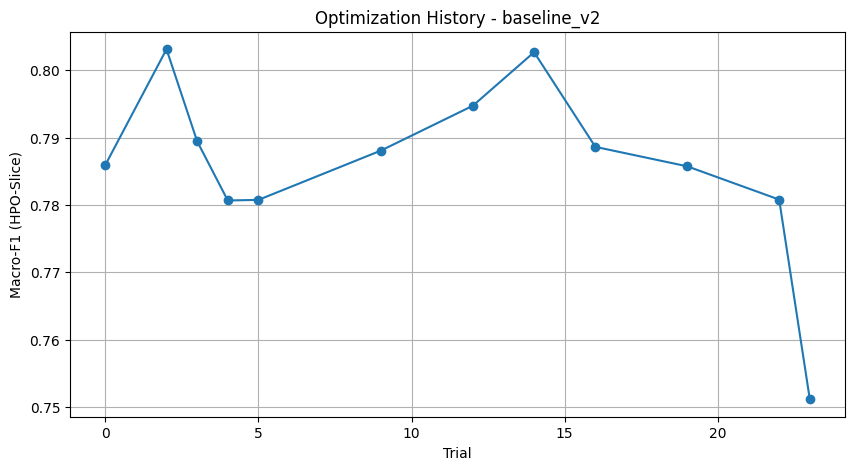

OK - test set not loaded in this notebook.


In [8]:
# Saved as JSON so kusa_baseline_cv_v2 reads it directly - especially the
# number of epochs, which it needs because there is no early stopping.
best = dict(study.best_params)              # head params only
best.update(FIXED_ENCODER)                  # encoder side was fixed, not searched
best["_hpo_slice_seed"] = HPO_SLICE_SEED
best["_variant"]     = VARIANT
best["_study"]       = STUDY_NAMES[VARIANT]
best["_best_value"]  = float(study.best_value)
best["_n_trials"]    = len([t for t in study.trials if t.state in FINISHED_STATES])
best["_hpo_frac"]    = HPO_FRAC
best["_hpo_seed"]    = HPO_SEED
best["_note"]        = ("own head search, same space and budget as dual_view_v2; "
                        "encoder fixed and shared across architectures")

with open(os.path.join(SAVE_DIR, "best_params.json"), "w", encoding="utf-8") as f:
    json.dump(best, f, indent=2)
print(json.dumps(best, indent=2))

try:
    tdf = study.trials_dataframe()
    tdf = tdf[tdf["state"] == "COMPLETE"].reset_index(drop=True)
    if len(tdf) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(tdf["number"], tdf["value"], marker="o")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Macro-F1 (HPO-Slice)")
        ax.set_title(f"Optimization History - {VARIANT}")
        ax.grid()
        plt.savefig(os.path.join(SAVE_DIR, "optimization_history.png"), dpi=150,
                    bbox_inches="tight")
        plt.show()
except Exception as e:
    print("Visualization failed:", e)

assert_test_untouched(globals())